<a href="https://colab.research.google.com/github/MoAbner/LIA1/blob/main/Entregas%20-%20Abner%20Gabriel/Aulas_8_e_9/Reuters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📑 Relatório de Análise: Classificação de Tópicos (Reuters Dataset)
**Disciplina:** LIA (Laboratório de Inovação e Automação 1)  
**Instituição:** UFG - Engenharia de Computação
* **Data:** 29 de Março de 2026

---
> ### 👤 Abner Gabriel Monteiro Tavares
> **GitHub:** [MoAbner](https://github.com/MoAbner)  
> **Contato:** `abner_gabriel@discente.ufg.br`  
> **Disciplina:** LIA (Laboratório de Inovação e Automação 1)
---

🚀 Sobre o Projeto
> **# 1. Introdução e Objetivo**
Este projeto aplica técnicas de Processamento de Linguagem Natural (NLP) e Aprendizado de Máquina Supervisionado para a classificação automática de notícias da agência Reuters. O objetivo principal é construir um modelo capaz de categorizar textos jornalísticos em 46 tópicos distintos (como economia, política e commodities), demonstrando a viabilidade de triagem automatizada de grandes volumes de informação textual.

> **# 2. Metodologia**
>A análise seguiu o protocolo de engenharia de dados voltado a textos:

>Vetorização de Texto: Conversão de sequências de palavras em representações numéricas (TF-IDF ou Bag-of-Words).

>Tratamento de Vocabulário: Limitação das palavras mais frequentes para reduzir o ruído e a dimensionalidade do modelo.

>Engenharia de Features: Aplicação de padding (em caso de redes neurais) ou normalização de frequência para equilibrar o peso de termos irrelevantes.

>Modelagem: Utilização do algoritmo Random Forest (ou MLP) configurado para classificação multiclasse, com foco em lidar com o desbalanceamento de tópicos (alguns temas possuem muito mais notícias que outros).

**Ferramentas Utilizadas:**
* **Linguagem:** Python 3.14
* **Bibliotecas:** **Keras/Scikit-Learn:** Para carregamento do dataset e divisão treino/teste. **Pandas & NumPy:** Manipulação das matrizes de adjacência e frequências. **Matplotlib & Seaborn:** Visualização da distribuição das 46 classes e matriz de confusão.

* **Dataset:** Reuters Newswire Dataset.
* **Link para o Dataset:** [Dataset](https://www.kaggle.com/datasets/thedevastator/uncovering-financial-insights-with-the-reuters-2)

---

## <font color='Black'>Projeto Ponta a Ponta - Construindo um Modelo com TensorFlow</font>

Construir um modelo de Inteligência Artificial capaz de classificar notícias considerando as categorias do dataset do Reuters: <font color= 'GRAY'> ['cacau', 'grãos', 'óleo vegetal', 'lucro', 'aquisição', 'trigo', 'cobre', 'habitação', 'oferta monetária', 'café', 'açúcar', 'comércio', 'reservas', 'navio', 'algodão', 'carcaça', 'petróleo bruto', 'gás natural', 'índice de preços ao consumidor (IPC)', 'câmbio', 'juros', 'produto nacional bruto (PNB)', 'ração', 'alumínio', 'oleaginosa', 'ouro', 'estanho', 'metal estratégico', 'pecuária', 'varejo', 'índice de produção industrial (IPI)', 'ferro-aço', 'borracha', 'calor', 'empregos', 'leading economic indicators (LEI)', 'balança de pagamentos', 'zinco', 'laranja', 'petroquímica', 'dólar', 'gás', 'prata', 'índice de preços no atacado (IPA)', 'suíno', 'chumbo']</font>. Dada uma nova nóticia de uma dessas categorias o modelo deve ser capaz de classificar e indicar o assunto da notícia.

Conheça o TensorFlow! -> https://www.tensorflow.org/

##📑 Visão Geral: Classificação de Tópicos (Reuters Dataset)
Este projeto tem como objetivo desenvolver um modelo de Processamento de Linguagem Natural (NLP) capaz de classificar textos de notícias do dataset Reuters em 46 categorias diferentes (como economia, grãos, petróleo, etc.).

A abordagem utiliza uma rede neural convolucional de uma dimensão (Conv1D), que é altamente eficiente para extrair padrões locais em sequências de texto, capturando a relação entre palavras vizinhas.

🛠️ Tecnologias e Técnicas Utilizadas
Dataset: reuters (Keras Datasets), composto por 11.228 notícias com um vocabulário indexado por frequência.

Pré-processamento: * Padding: Padronização do comprimento das sequências para o 95º percentil do tamanho dos textos, garantindo entrada uniforme na rede.

Mapeamento de Labels: Tradução das categorias originais para o português para melhor interpretabilidade dos resultados.

Arquitetura do Modelo (CNN):

Camada de Embedding: Transforma índices numéricos em vetores densos de 128 dimensões.

Conv1D: 128 filtros com janela de tamanho 5 para detecção de padrões textuais.

Global Max Pooling: Reduz a dimensionalidade extraindo as características mais importantes de cada filtro.

Dense Layers: Camadas totalmente conectadas com ativação ReLU para aprendizado de alto nível e Softmax para a classificação multiclasse final.

Otimização: Compilado com o otimizador Adam e função de perda sparse_categorical_crossentropy.

## Instalando e importando as Dependências

In [ ]:
# Instala o TF
#!pip install -q tensorflow==2.12
!pip install -q tensorflow

In [ ]:
# Silencia mensagens do TF
%env TF_CPP_MIN_LOG_LEVEL=3

env: TF_CPP_MIN_LOG_LEVEL=3


In [ ]:
# Imports
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.callbacks import ModelCheckpoint
from PIL import Image
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import confusion_matrix

In [ ]:
# Versão da Linguagem Python
from platform import python_version
print('Versão do Python neste Notebook:', python_version())


Versão do Python neste Notebook: 3.12.13



## Carregando os dados - matéria prima


In [ ]:
# Carrega o dataset Reuters
print('Carregando o dataset Reuters...')
(imagens_treino, labels_treino), (imagens_teste, labels_teste) = datasets.reuters.load_data()
print('Dataset Reuters carregado com sucesso.')

Carregando o dataset Reuters...
Dataset Reuters carregado com sucesso.



# Classes das imagens

In [ ]:
# Determina o número máximo de palavras no vocabulário
# Somamos 3 para os tokens especiais (padding, start-of-sequence, unknown)
max_words = len(word_index) + 3

# Determina o comprimento máximo das sequências (maxlen)
# Usaremos o percentil 95 do comprimento das sequências para cobrir a maioria dos textos.
train_lengths = [len(x) for x in imagens_treino]
test_lengths = [len(x) for x in imagens_teste]
all_lengths = train_lengths + test_lengths
maxlen = int(np.percentile(all_lengths, 95))

print('Aplicando padding às sequências...')
# Aplica o padding às sequências de treino e teste
imagens_treino_padded = pad_sequences(imagens_treino, maxlen=maxlen)
imagens_teste_padded = pad_sequences(imagens_teste, maxlen=maxlen)

print(f"Número máximo de palavras no vocabulário (input_dim para Embedding): {max_words}")
print(f"Comprimento máximo da sequência (maxlen para padding): {maxlen}")
print(f"Shape das imagens_treino_padded (após padding): {imagens_treino_padded.shape}")
print(f"Shape das imagens_teste_padded (após padding): {imagens_teste_padded.shape}")
print('\nPré-processamento dos dados (padding) concluído!')

Aplicando padding às sequências...
Número máximo de palavras no vocabulário (input_dim para Embedding): 30982
Comprimento máximo da sequência (maxlen para padding): 460
Shape das imagens_treino_padded (após padding): (8982, 460)
Shape das imagens_teste_padded (após padding): (2246, 460)

Pré-processamento dos dados (padding) concluído!


In [ ]:
# Exibe os primeiros elementos de labels_treino (categorias)
print('Primeiros 5 labels de treino:')
print(labels_treino[:5])

Primeiros 5 labels de treino:
[3 4 3 4 4]


Como você pode ver, `imagens_treino` contém sequências de números inteiros, onde cada número representa uma palavra no vocabulário. `labels_treino` são os rótulos de categoria para cada uma dessas sequências de texto.

In [ ]:
# Para decodificar as sequências numéricas de volta para texto, precisamos do dicionário de palavras.
# O Reuters dataset inclui uma função para obter o word_index.
# O word_index já é carregado na célula inicial, então não precisamos carregá-lo novamente aqui.

# Inverte o word_index para mapear números de volta para palavras
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

# Decodifica um texto de exemplo
def decode_review(text):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in text])

# Decodifica o primeiro texto de treino
print('\nPrimeiro texto decodificado de treino:')
print(decode_review(imagens_treino[0]))


Primeiro texto decodificado de treino:
? mcgrath rentcorp said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3



## Pre-processamento e visualizção do que tem no Dataset


In [ ]:
# Nomes das categorias em inglês
print('Obtendo nomes das classes em inglês...')
reuters_english_labels = datasets.reuters.get_label_names()
print('Nomes das classes em inglês obtidos.')

Obtendo nomes das classes em inglês...
Nomes das classes em inglês obtidos.


In [ ]:
# Mapeamento para português (uma tradução aproximada para algumas categorias)
# Você pode ajustar estas traduções conforme a necessidade do seu projeto.
reuters_portuguese_labels_map = {
    'cocoa': 'cacau', 'grain': 'grãos', 'veg-oil': 'óleo vegetal', 'earn': 'lucro', 'acq': 'aquisição',
    'wheat': 'trigo', 'copper': 'cobre', 'housing': 'habitação', 'money-supply': 'oferta monetária',
    'coffee': 'café', 'sugar': 'açúcar', 'trade': 'comércio', 'reserves': 'reservas', 'ship': 'navio',
    'cotton': 'algodão', 'carcass': 'carcaça', 'crude': 'petróleo bruto', 'nat-gas': 'gás natural',
    'cpi': 'índice de preços ao consumidor (IPC)', 'money-fx': 'câmbio', 'interest': 'juros',
    'gnp': 'produto nacional bruto (PNB)', 'meal-feed': 'ração', 'alum': 'alumínio',
    'oilseed': 'oleaginosa', 'gold': 'ouro', 'tin': 'estanho', 'strategic-metal': 'metal estratégico',
    'livestock': 'pecuária', 'retail': 'varejo', 'ipi': 'índice de produção industrial (IPI)',
    'iron-steel': 'ferro-aço', 'rubber': 'borracha', 'heat': 'calor', 'jobs': 'empregos',
    'lei': 'leading economic indicators (LEI)', 'bop': 'balança de pagamentos', 'zinc': 'zinco',
    'orange': 'laranja', 'pet-chem': 'petroquímica', 'dlr': 'dólar', 'gas': 'gás', 'silver': 'prata',
    'wpi': 'índice de preços no atacado (IPA)', 'hog': 'suíno', 'lead': 'chumbo'
}

# Cria uma lista de nomes de classes em português na mesma ordem que os labels numéricos
nomes_classes_reuters_pt = [reuters_portuguese_labels_map.get(label, label) for label in reuters_english_labels]

num_classes_reuters = len(nomes_classes_reuters_pt) # Define num_classes_reuters aqui

print("Passando as categorias para português:", nomes_classes_reuters_pt[:])
print(f'Número de classes: {num_classes_reuters}')

Passando as categorias para português: ['cacau', 'grãos', 'óleo vegetal', 'lucro', 'aquisição', 'trigo', 'cobre', 'habitação', 'oferta monetária', 'café', 'açúcar', 'comércio', 'reservas', 'navio', 'algodão', 'carcaça', 'petróleo bruto', 'gás natural', 'índice de preços ao consumidor (IPC)', 'câmbio', 'juros', 'produto nacional bruto (PNB)', 'ração', 'alumínio', 'oleaginosa', 'ouro', 'estanho', 'metal estratégico', 'pecuária', 'varejo', 'índice de produção industrial (IPI)', 'ferro-aço', 'borracha', 'calor', 'empregos', 'leading economic indicators (LEI)', 'balança de pagamentos', 'zinco', 'laranja', 'petroquímica', 'dólar', 'gás', 'prata', 'índice de preços no atacado (IPA)', 'suíno', 'chumbo']
Número de classes: 46


In [ ]:
# Mostra uma parte do word_index para verificação
print('Exemplo do word_index:')
print(list(word_index.items())[:10])

Exemplo do word_index:
[('mdbl', 10996), ('fawc', 16260), ('degussa', 12089), ('woods', 8803), ('hanging', 13796), ('localized', 20672), ('sation', 20673), ('chanthaburi', 20675), ('refunding', 10997), ('hermann', 8804)]


Primeiro, vamos carregar o `word_index` novamente para ter certeza de que temos a versão mais recente.

In [ ]:
# Para garantir que temos o dicionário de palavras mais recente
print('Carregando o word_index...')
word_index = datasets.reuters.get_word_index(path='reuters_word_index.json')
print('Word_index carregado.')

Carregando o word_index...
Word_index carregado.


Agora, vamos converter o dicionário em uma lista de tuplas (palavra, índice) e ordená-lo. Como os índices mais altos correspondem às palavras menos frequentes, para ordenar da 'menos usada' para a 'mais usada', ordenamos pelo índice em ordem decrescente. No entanto, para exibir o 'crescente' em termos de frequência, podemos ordenar o índice de forma ascendente e então percorrer a lista.

In [ ]:
# Converte o dicionário word_index em uma lista de tuplas (palavra, índice)
# e ordena pela frequência (índice), do mais frequente (menor índice) para o menos frequente (maior índice).
# Lembre-se que 0, 1, 2 são tokens especiais, então palavras reais começam em 3.

sorted_word_index_asc = sorted([(word, idx) for word, idx in word_index.items() if idx >= 3], key=lambda item: item[1])
print('Converte o dicionário word_index em uma lista de tuplas (palavra, índice)')
print('Ordena pela frequência (índice), do mais frequente (menor índice) para o menos frequente (maior índice)')
print('Todas as palavras ranqueadas do mais usado (maior índice) para o menos usado (menor índice):')
for word, idx in sorted_word_index_asc:
    print(f'Palavra: "{word}", Índice: {idx}')

A saída de streaming foi truncada nas últimas 5000 linhas.
Palavra: "anamoly", Índice: 25980
Palavra: "sited", Índice: 25981
Palavra: "ibrd", Índice: 25982
Palavra: "ascribed", Índice: 25983
Palavra: "stabalizing", Índice: 25984
Palavra: "gnsp", Índice: 25985
Palavra: "oust", Índice: 25986
Palavra: "beliz", Índice: 25987
Palavra: "skittish", Índice: 25988
Palavra: "algerians", Índice: 25989
Palavra: "banstead", Índice: 25990
Palavra: "caring", Índice: 25991
Palavra: "medtec's", Índice: 25992
Palavra: "toyota's", Índice: 25993
Palavra: "conveyance", Índice: 25994
Palavra: "endured", Índice: 25995
Palavra: "ivb", Índice: 25996
Palavra: "wingnut", Índice: 25997
Palavra: "enrich", Índice: 25998
Palavra: "mons", Índice: 25999
Palavra: "structurally", Índice: 26000
Palavra: "transceiver", Índice: 26001
Palavra: "6735", Índice: 26002
Palavra: "cryogenics", Índice: 26003
Palavra: "ysec", Índice: 26004
Palavra: "mohawk", Índice: 26005
Palavra: "electrion", Índice: 26006
Palavra: "6080", Índice:

In [ ]:
sorted_word_index_asc = sorted([(word, idx) for word, idx in word_index.items() if idx >= 3], key=lambda item: item[1])

print('As 10 palavras MENOS usadas (índices mais altos):')
# Para as menos usadas, pegamos as últimas da lista ordenada em ordem ascendente de índice
for word, idx in sorted_word_index_asc[-10:]:
    print(f'Palavra: "{word}", Índice: {idx}')

print('\nAs 10 palavras MAIS usadas (índices mais baixos):')
# Para as mais usadas, pegamos as primeiras da lista ordenada em ordem ascendente de índice
for word, idx in sorted_word_index_asc[:10]:
    print(f'Palavra: "{word}", Índice: {idx}')

As 10 palavras MENOS usadas (índices mais altos):
Palavra: "clampdown", Índice: 30970
Palavra: "corporacion", Índice: 30971
Palavra: "staalfabrieken", Índice: 30972
Palavra: "odilon", Índice: 30973
Palavra: "guard's", Índice: 30974
Palavra: "recirculation", Índice: 30975
Palavra: "capco", Índice: 30976
Palavra: "figueras", Índice: 30977
Palavra: "jung", Índice: 30978
Palavra: "northerly", Índice: 30979

As 10 palavras MAIS usadas (índices mais baixos):
Palavra: "to", Índice: 3
Palavra: "in", Índice: 4
Palavra: "said", Índice: 5
Palavra: "and", Índice: 6
Palavra: "a", Índice: 7
Palavra: "mln", Índice: 8
Palavra: "3", Índice: 9
Palavra: "for", Índice: 10
Palavra: "vs", Índice: 11
Palavra: "dlrs", Índice: 12


### 1. Definição do Modelo CNN

In [ ]:
# Determina o número de classes para a camada de saída
# Assumimos que 'nomes_classes_reuters_pt' está definido
num_classes_reuters = len(nomes_classes_reuters_pt)

modelo_texto_reuters_cnn = models.Sequential()

# Camada de Embedding:
# Converte os índices numéricos das palavras em vetores densos de tamanho fixo.
# input_dim: o tamanho do vocabulário (max_words, assumido já definido).
# output_dim: a dimensão dos vetores de embedding (e.g., 128).
# input_length: o comprimento máximo das sequências de entrada (maxlen, assumido já definido).
modelo_texto_reuters_cnn.add(layers.Embedding(input_dim=max_words, output_dim=128, input_length=maxlen))

# Camada Conv1D:
# Aplica uma convolução 1D sobre a sequência de embeddings.
modelo_texto_reuters_cnn.add(layers.Conv1D(filters=128, kernel_size=5, activation='relu'))

# Camada GlobalMaxPooling1D:
# Reduz cada mapa de características 1D para um único valor.
modelo_texto_reuters_cnn.add(layers.GlobalMaxPooling1D())

# Camada Densa (Fully Connected) com Ativação ReLU:
modelo_texto_reuters_cnn.add(layers.Dense(64, activation='relu'))

# Camada de Saída Densa com Ativação Softmax:
# O número de neurônios deve ser igual ao número total de classes.
modelo_texto_reuters_cnn.add(layers.Dense(num_classes_reuters, activation='softmax'))

print("Modelo CNN definido:")
# O formato de entrada é (batch_size, maxlen)
# Usamos 'None' para o batch_size para aceitar qualquer tamanho
modelo_texto_reuters_cnn.build(input_shape=(None, maxlen))
modelo_texto_reuters_cnn.summary()

Modelo CNN definido:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 460, 128)       │     3,965,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 456, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 46)             │         2,990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,058,990 (15.48 MB)

 Trainable params: 4,058,990 (15.48 MB)

 Non-trainable params: 0 (0.00 B)

### 2. Compilação e Treinamento do Modelo CNN

In [ ]:
%%time

# Define o callback ModelCheckpoint para salvar o melhor modelo
# Monitora a 'val_loss' e salva o modelo apenas quando houver melhora
checkpoint_filepath = 'best_model_reuters_cnn.keras' # Nome do arquivo para salvar o modelo
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False, # Salva o modelo inteiro (arquitetura + pesos)
    monitor='val_loss',
    mode='min', # Queremos minimizar a perda de validação
    save_best_only=True,
    verbose=1
)

# Compilação do Modelo CNN
modelo_texto_reuters_cnn.compile(optimizer = 'adam',
                   loss = 'sparse_categorical_crossentropy',
                   metrics = ['accuracy'])

print("Modelo CNN compilado.\n")

# Treinamento do Modelo CNN
# Assumimos que 'imagens_treino_padded', 'labels_treino', 'imagens_teste_padded', 'labels_teste' estão definidos.
print("Iniciando o treinamento do Modelo CNN...")
history_texto_cnn = modelo_texto_reuters_cnn.fit(imagens_treino_padded,
                                 labels_treino,
                                 epochs = 25,
                                 validation_data = (imagens_teste_padded, labels_teste),
                                 callbacks=[model_checkpoint_callback]) # Adiciona o callback aqui

print("\nTreinamento do Modelo CNN concluído.")

Modelo CNN compilado.

Iniciando o treinamento do Modelo CNN...
Epoch 1/25
281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.4511 - loss: 2.3480
Epoch 1: val_loss improved from None to 1.40840, saving model to best_model_reuters_cnn.keras

Epoch 1: finished saving model to best_model_reuters_cnn.keras
281/281 ━━━━━━━━━━━━━━━━━━━━ 78s 262ms/step - accuracy: 0.5613 - loss: 1.8506 - val_accuracy: 0.6630 - val_loss: 1.4084
Epoch 2/25
281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.7347 - loss: 1.1136
Epoch 2: val_loss improved from 1.40840 to 1.01431, saving model to best_model_reuters_cnn.keras

Epoch 2: finished saving model to best_model_reuters_cnn.keras
281/281 ━━━━━━━━━━━━━━━━━━━━ 73s 232ms/step - accuracy: 0.7521 - loss: 1.0543 - val_accuracy: 0.7596 - val_loss: 1.0143
Epoch 3/25
281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.8349 - loss: 0.6982
Epoch 3: val_loss improved from 1.01431 to 0.88269, saving model to best_model_reuters_cnn.keras

Epoch 3: finish

### 3. Avaliação do Modelo CNN

In [ ]:
# Avalia o modelo no conjunto de teste
erro_teste_texto_cnn, acc_teste_texto_cnn = modelo_texto_reuters_cnn.evaluate(imagens_teste_padded, labels_teste, verbose = 2)

print(f'\nAcurácia com dados de Teste (Modelo de Texto CNN): {acc_teste_texto_cnn:.4f}')
print(f'Erro com dados de Teste (Modelo de Texto CNN): {erro_teste_texto_cnn:.4f}')

71/71 - 4s - 54ms/step - accuracy: 0.7930 - loss: 1.1163

Acurácia com dados de Teste (Modelo de Texto CNN): 0.7930
Erro com dados de Teste (Modelo de Texto CNN): 1.1163


### 4. Matriz de Confusão do Modelo CNN

71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step


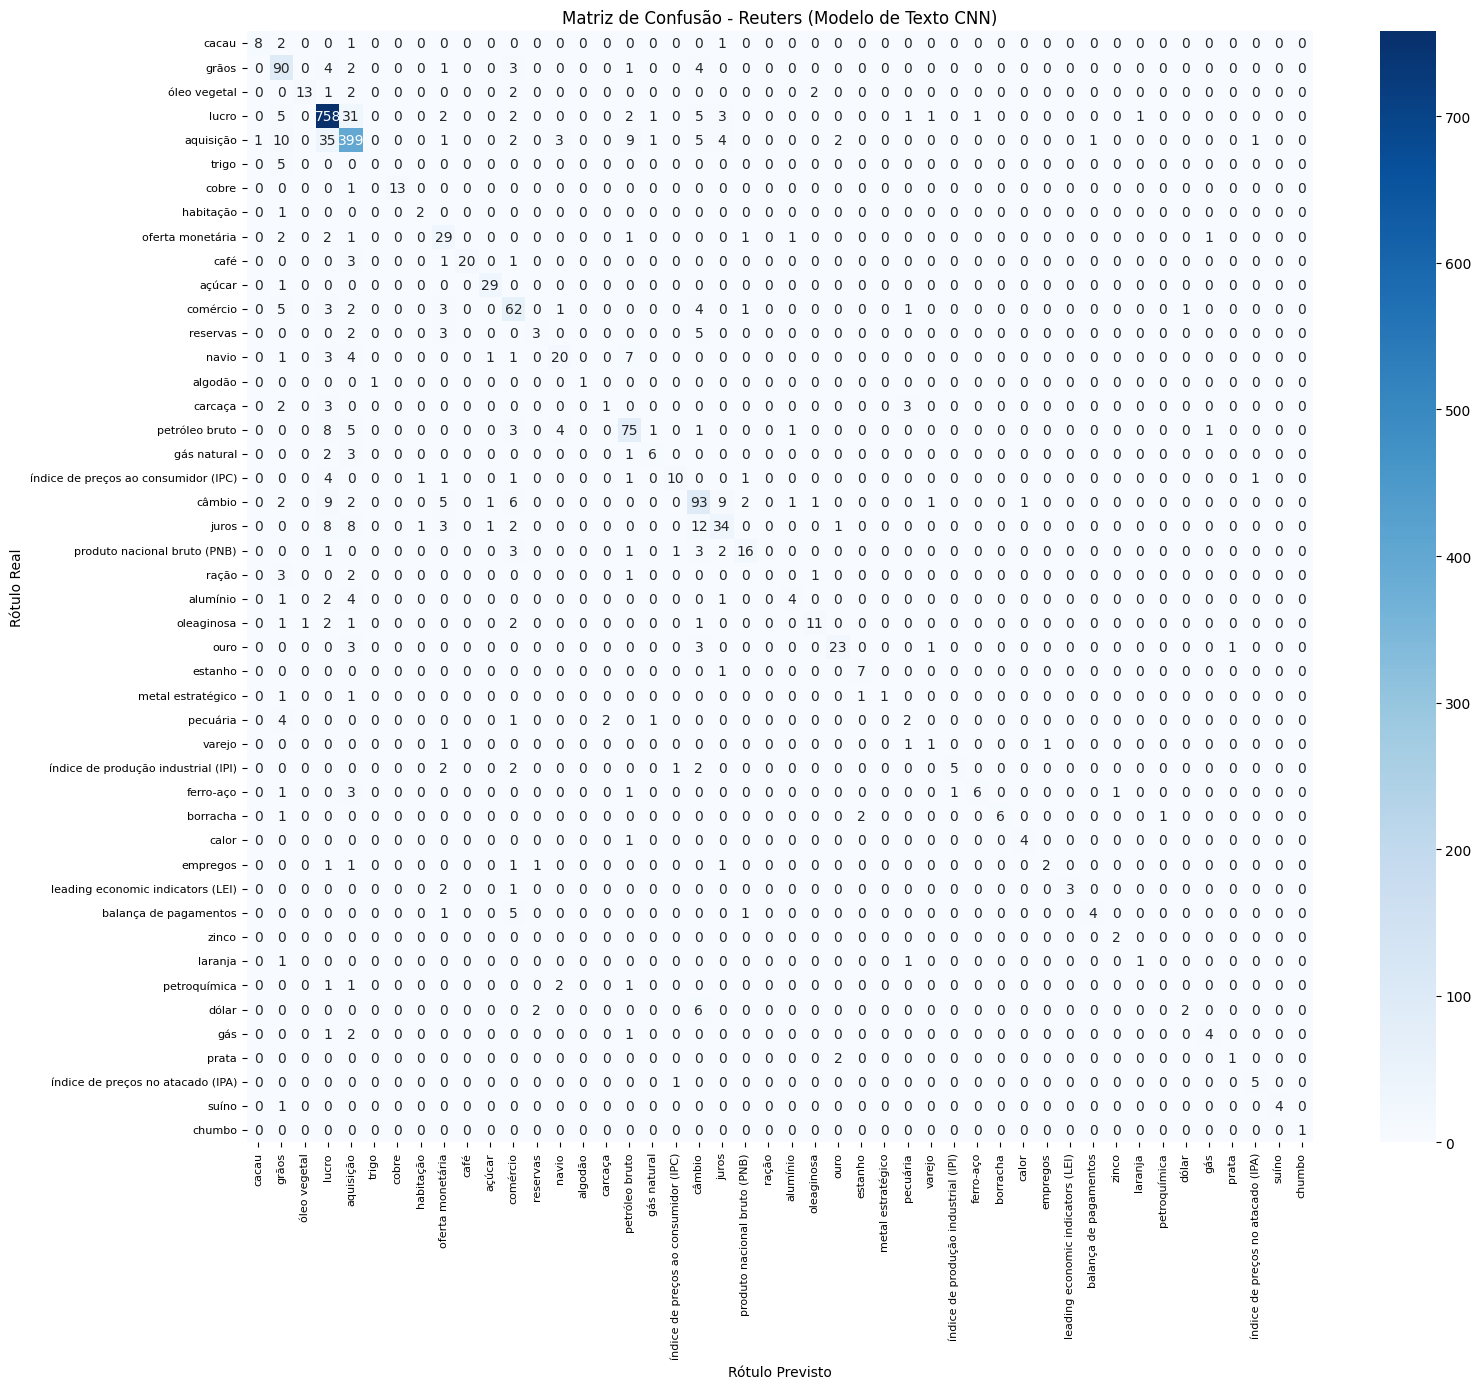

In [ ]:
# Previsões do modelo no conjunto de teste
y_pred_texto_cnn = modelo_texto_reuters_cnn.predict(imagens_teste_padded)
y_pred_classes_texto_cnn = np.argmax(y_pred_texto_cnn, axis=1)

# Labels verdadeiros (assumimos 'labels_teste' está definido)
y_true_texto = labels_teste

# Geração da matriz de confusão
cm_texto_cnn = confusion_matrix(y_true_texto, y_pred_classes_texto_cnn)

# Impressão da matriz de confusão
plt.figure(figsize=(16, 14))
sns.heatmap(cm_texto_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=nomes_classes_reuters_pt,
            yticklabels=nomes_classes_reuters_pt)
plt.title('Matriz de Confusão - Reuters (Modelo de Texto CNN)')
plt.xlabel('Rótulo Previsto')
plt.ylabel('Rótulo Real')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

### 5. Análise de Erros: Exemplos Mal Classificados

In [ ]:
import numpy as np

# Encontra os índices dos exemplos mal classificados pelo modelo CNN
misclassified_indices_cnn = np.where(y_true_texto != y_pred_classes_texto_cnn)[0]

print(f"Total de exemplos mal classificados pelo modelo CNN: {len(misclassified_indices_cnn)}")

# Exibe os primeiros 10 exemplos mal classificados (ou menos, se não houver 10)
num_to_display_cnn = min(10, len(misclassified_indices_cnn))

print(f"\nExibindo os primeiros {num_to_display_cnn} exemplos mal classificados pelo modelo CNN:\n")

for i in range(num_to_display_cnn):
    idx = misclassified_indices_cnn[i]
    # Decodifica o texto original (assumimos 'decode_review' e 'imagens_teste' estão definidos)
    original_text = decode_review(imagens_teste[idx])
    true_label = nomes_classes_reuters_pt[y_true_texto[idx]]
    predicted_label = nomes_classes_reuters_pt[y_pred_classes_texto_cnn[idx]]

    print(f"--- Exemplo {i+1} ---")
    print(f"Texto: {original_text[:200]}...") # Limita para facilitar a leitura
    print(f"Rótulo Real: {true_label}")
    print(f"Rótulo Previsto: {predicted_label}")
    print("\n")

Total de exemplos mal classificados pelo modelo CNN: 465

Exibindo os primeiros 10 exemplos mal classificados pelo modelo CNN:

--- Exemplo 1 ---
Texto: ? graham mccormick oil and gas partnership said it completed the sale of interests in two major oil and gas fields to lt energy assets international corp for 21 mln dlrs the company said it sold about...
Rótulo Real: aquisição
Rótulo Previsto: petróleo bruto


--- Exemplo 2 ---
Texto: ? strong south easterly winds were keeping many vessels trapped in the ice off the finnish and swedish coasts in one of the worst icy periods in the baltic for many years the finnish board of navigati...
Rótulo Real: aquisição
Rótulo Previsto: navio


--- Exemplo 3 ---
Texto: ? grain traders said they were still awaiting results of yesterday's u k intervention feed wheat tender for the home market the market sought to buy 340 000 tonnes more than double the remaining 150 0...
Rótulo Real: trigo
Rótulo Previsto: grãos


--- Exemplo 4 ---
Texto: ? investite

### 6. Deploy do modelo

In [ ]:
# Função auxiliar para pré-processar nova notícia (assumimos 'word_index' e 'maxlen' estão definidos)
def preprocess_new_text(text, word_index):
    tokens = []
    for word in text.lower().split():
        token = word_index.get(word, 2) + 3 # Offset de 3 para tokens especiais (similar ao reuters.load_data())
        tokens.append(token)
    return [1] + tokens # Adicionar o token de 'start of sequence' (1)

# 1. Definir a nova notícia/texto para classificação
nova_noticia_cnn = input("Coloque aqui a notícia para classificação: ")

# 2. Pré-processar a nova notícia
sequencia_numerica_noticia_cnn = preprocess_new_text(nova_noticia_cnn, word_index)
nova_noticia_padded_cnn = pad_sequences([sequencia_numerica_noticia_cnn], maxlen=maxlen)

print(f"\nNova notícia pré-processada (padded): {nova_noticia_padded_cnn}")
print(f"Shape da notícia pré-processada: {nova_noticia_padded_cnn.shape}")

# 3. Fazer a previsão com o modelo de texto CNN
previsoes_noticia_cnn = modelo_texto_reuters_cnn.predict(nova_noticia_padded_cnn)

# 4. Obter a classe prevista (o índice com a maior probabilidade)
classe_prevista_indice_cnn = np.argmax(previsoes_noticia_cnn)

# 5. Decodificar o índice da classe para o nome da categoria em português (assumimos 'nomes_classes_reuters_pt' está definido)
nome_categoria_prevista_cnn = nomes_classes_reuters_pt[classe_prevista_indice_cnn]


Coloque aqui a notícia para classificação: GOLD is a mineral

Nova notícia pré-processada (padded): [[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0

## 7. Mostrando o resultado

In [ ]:
print(f"{nova_noticia_cnn}")
print(f"\n🚀 Probabilidades de previsão (Modelo CNN): {previsoes_noticia_cnn}")
print(f"A notícia foi classificada pelo Modelo CNN como: {nome_categoria_prevista_cnn} (Índice: {classe_prevista_indice_cnn})")

GOLD is a mineral

🚀 Probabilidades de previsão (Modelo CNN): [[4.13094298e-04 4.24665777e-04 1.39592021e-06 1.71432446e-04
  6.10639283e-04 4.51340298e-07 5.81595697e-04 2.83771951e-04
  1.98770140e-04 1.79089075e-05 1.51966664e-03 4.31227600e-05
  1.34375616e-04 8.16994347e-04 6.64897088e-04 3.85555313e-06
  5.96075319e-04 2.14183331e-03 3.25339133e-05 1.49997370e-03
  6.85245031e-05 3.00033353e-05 4.52937929e-05 2.93541252e-05
  8.00294583e-06 9.71031487e-01 4.30185537e-05 1.26460509e-04
  1.18486760e-05 2.80431796e-05 4.24842554e-04 1.26285871e-04
  8.76736885e-04 2.14523752e-07 1.12561816e-06 8.92739820e-07
  4.98093723e-04 1.51567674e-05 1.03268900e-03 4.42261895e-04
  4.99363383e-03 1.42866644e-04 9.76148807e-03 3.17490480e-06
  8.94473269e-05 1.20708755e-05]]
A notícia foi classificada pelo Modelo CNN como: ouro (Índice: 25)
